In [ ]:
!pip install yfinance scikit-learn seaborn tensorflow statsmodels

In [ ]:

import yfinance as yf
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
import joblib



In [ ]:
df = pd.read_csv(r'C:\Users\gerem\Desktop\projeto_tc_fiap_4\data\raw\data_2026_04_13.csv')

In [ ]:
df.columns = df.columns.get_level_values(0)
df = df.iloc[2:]

In [ ]:
df = df.rename(columns={'Price': 'data', 'Close': 'fechamento', 'High':'maxima', 'Low': 'minima', 'Open': 'abertura', 'Volume': 'volume'})


In [ ]:
df = df[df['data'] > '2021-01-01']

In [ ]:
df.head()

,data,fechamento,maxima,minima,abertura,volume
3979,2021-01-04,12.45572280883789,13.019030555367095,12.425900596844345,12.999148659362074,27749200
3980,2021-01-05,12.326491355895996,12.409330677825368,12.160812712037254,12.409330677825368,31908000
3981,2021-01-06,12.608150482177734,12.833473645055289,12.386141601593625,12.43584445974029,41133400
3982,2021-01-07,13.108492851257324,13.154882662548532,12.565065916628368,12.631337617341906,43757400
3983,2021-01-08,13.184709548950195,13.439854865727781,13.01903087031758,13.204590181408186,32480600


In [ ]:
df["data"] = pd.to_datetime(df["data"])

numeric_cols = ["fechamento", "maxima", "minima", "abertura", "volume"]
df[numeric_cols] = df[numeric_cols].astype(float)

In [ ]:
df.dtypes

data          datetime64[us]
fechamento           float64
maxima               float64
minima               float64
abertura             float64
volume               float64
dtype: object

In [ ]:
df['return'] = df['fechamento'].pct_change()
df['range'] = df['maxima'] - df['minima']
df['variacao'] = df['fechamento'] - df['abertura']
df['vol_10'] = df['return'].rolling(10).std()
df['vol_20'] = df['return'].rolling(20).std()
df['fechamento_1d'] = df['fechamento'].shift(1)
df['fechamento_2d'] = df['fechamento'].shift(2)
df['fechamento_3d'] = df['fechamento'].shift(3)
df['sma_5'] = df['fechamento'].rolling(5).mean()
df['sma_10'] = df['fechamento'].rolling(10).mean()
df['sma_20'] = df['fechamento'].rolling(20).mean()
df['ema_5'] = df['fechamento'].ewm(span=5).mean()
df['ema_10'] = df['fechamento'].ewm(span=10).mean()
df['mom_5'] = df['fechamento'] - df['fechamento'].shift(5)
df['mom_10'] = df['fechamento'] - df['fechamento'].shift(10)
df['target'] = df['fechamento'].shift(-1)

delta = df['fechamento'].diff()

gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / loss
df['rsi'] = 100 - (100 / (1 + rs))

df = df.dropna()

In [ ]:
(df.isna().sum() / df.shape[0] * 100).sort_values(ascending = False)

data             0.0
fechamento       0.0
maxima           0.0
minima           0.0
abertura         0.0
volume           0.0
return           0.0
range            0.0
variacao         0.0
vol_10           0.0
vol_20           0.0
fechamento_1d    0.0
fechamento_2d    0.0
fechamento_3d    0.0
sma_5            0.0
sma_10           0.0
sma_20           0.0
ema_5            0.0
ema_10           0.0
mom_5            0.0
mom_10           0.0
target           0.0
rsi              0.0
dtype: float64

In [ ]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
data,1293,2023-09-05 14:17:32.436195,2021-02-02 00:00:00,2022-05-23 00:00:00,2023-09-04 00:00:00,2024-12-18 00:00:00,2026-04-09 00:00:00,NaN
fechamento,1293.0,18.592229,9.373324,12.776587,20.172001,23.860001,28.749609,5.657628
maxima,1293.0,18.801314,9.686217,12.93366,20.401075,24.027361,29.020105,5.686255
minima,1293.0,18.389904,9.090713,12.630221,19.978866,23.65,28.527418,5.619969
abertura,1293.0,18.596722,9.235384,12.770402,20.232189,23.860728,28.749607,5.654432
volume,1293.0,26692137.587007,0.0,16258400.0,22242600.0,31663000.0,204072200.0,16930761.034744
return,1293.0,0.000752,-0.126871,-0.008063,0.000851,0.010481,0.076324,0.01731
range,1293.0,0.41141,0.0,0.274434,0.362588,0.488258,2.33451,0.211941
variacao,1293.0,-0.004493,-1.572828,-0.148035,-0.008004,0.147772,1.594079,0.272147
vol_10,1293.0,0.01569,0.004453,0.01053,0.014071,0.019541,0.052547,0.007269


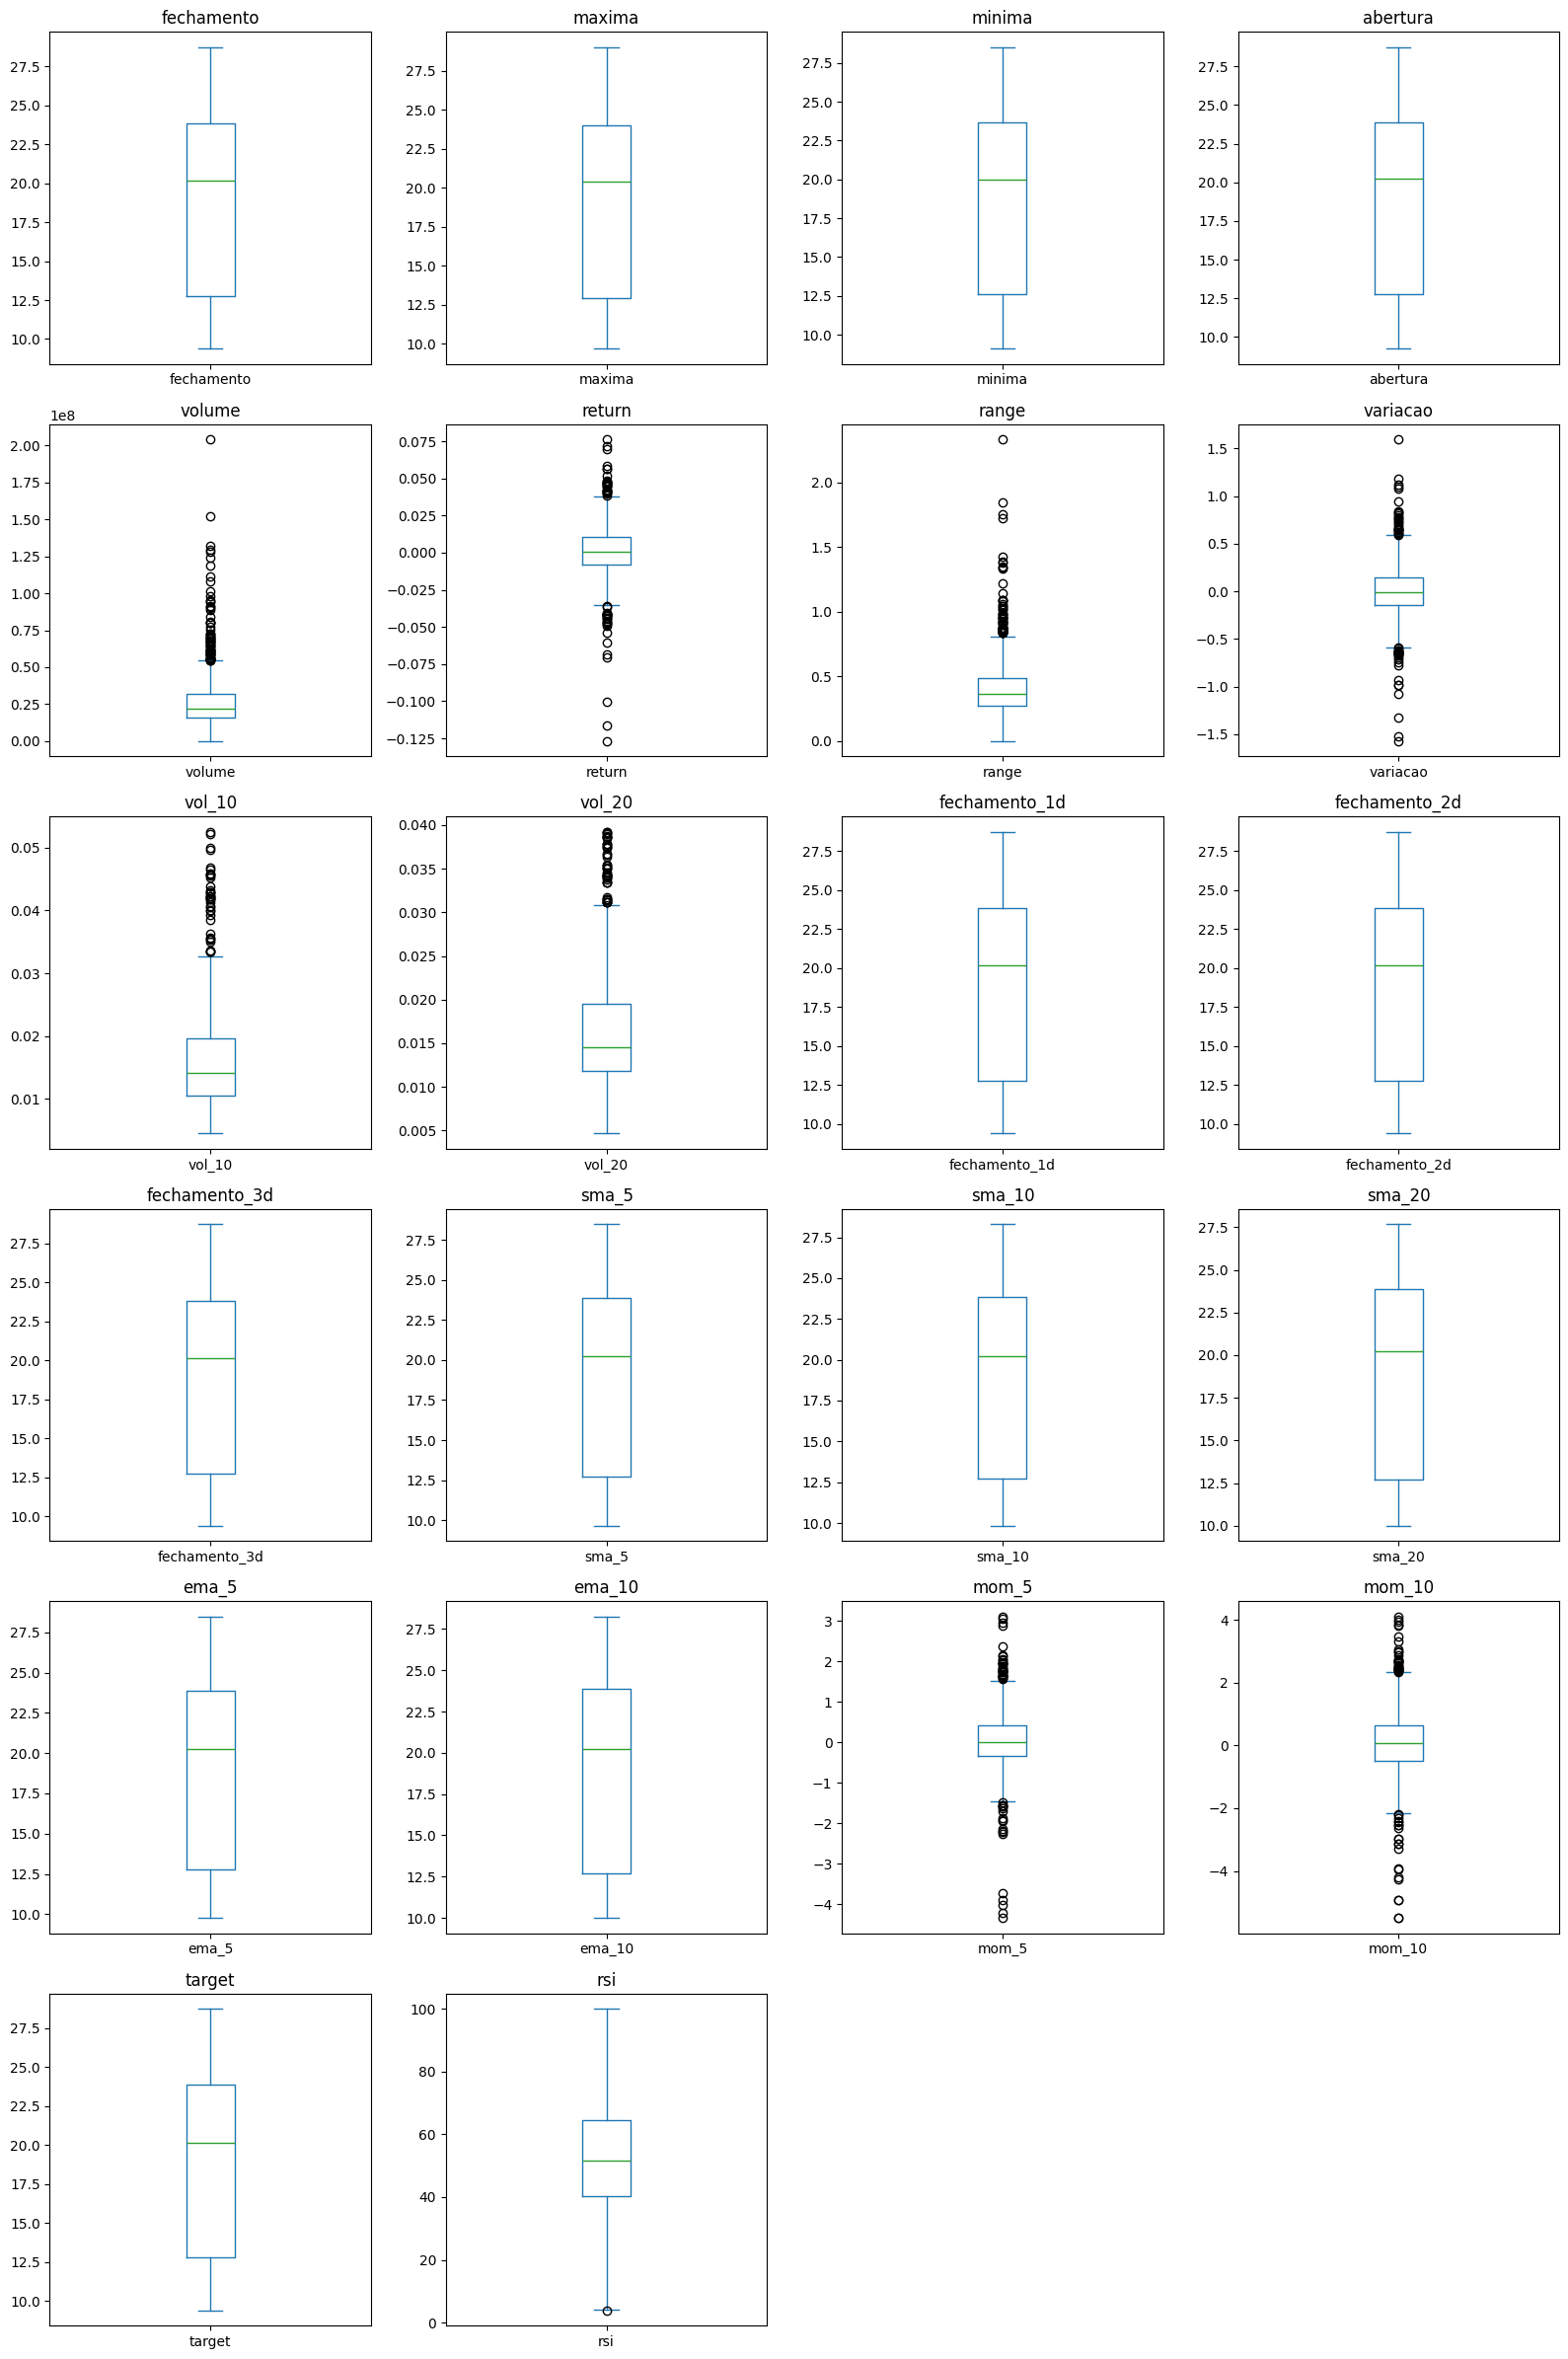

In [ ]:
cols = df.select_dtypes(include='number').columns

ncols = 4
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    df[col].plot(kind='box', ax=ax)
    ax.set_title(col)

for ax in axes[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

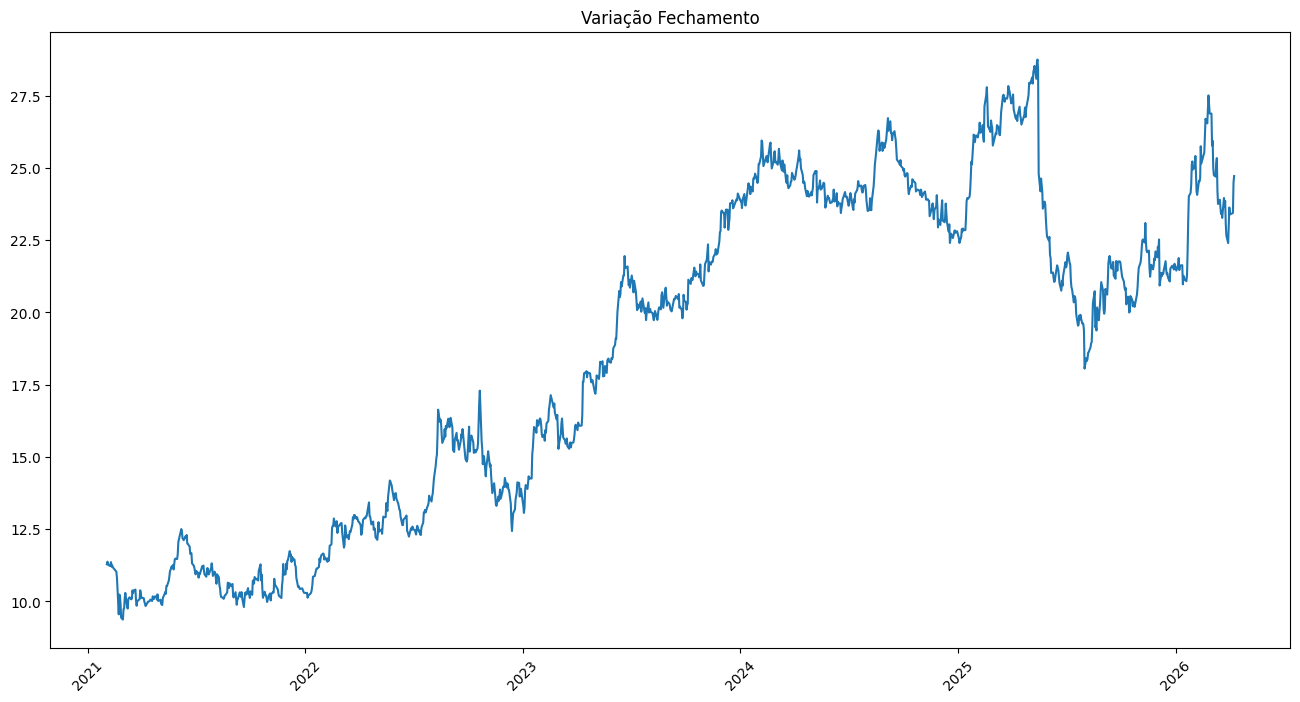

In [ ]:
plt.figure(figsize=(16,8))
plt.title('Variação Fechamento')

plt.plot(df['data'], df['fechamento'])
plt.xticks(rotation=45) 
plt.show()


In [ ]:
df.shape

(1293, 23)

In [ ]:
df.columns

Index(['data', 'fechamento', 'maxima', 'minima', 'abertura', 'volume',
       'return', 'range', 'variacao', 'vol_10', 'vol_20', 'fechamento_1d',
       'fechamento_2d', 'fechamento_3d', 'sma_5', 'sma_10', 'sma_20', 'ema_5',
       'ema_10', 'mom_5', 'mom_10', 'target', 'rsi'],
      dtype='str')

In [ ]:
df_modelo = df[['fechamento',
        'volume',
        'sma_5',
        'sma_10',
        'vol_10',
        'mom_5',
        'target',
        'maxima',
        'minima',
        'variacao',
        'abertura']]
df_modelo

,fechamento,volume,sma_5,sma_10,vol_10,mom_5,target,maxima,minima,variacao,abertura
3999,11.286030,39601800.0,11.299285,11.299617,0.019843,0.420821,11.375498,11.630640,11.213131,-0.231949,11.517979
4000,11.375498,20946000.0,11.337723,11.266812,0.019757,0.192186,11.329109,11.511354,11.325794,0.009942,11.365556
4001,11.329109,20148400.0,11.314528,11.255546,0.018539,-0.115973,11.252894,11.504729,11.272779,-0.135856,11.464966
4002,11.252894,25487200.0,11.321155,11.248256,0.018380,0.033135,11.223073,11.425200,11.199877,-0.106034,11.358929
4003,11.223073,23303200.0,11.293321,11.254221,0.017763,-0.139172,11.358929,11.348989,11.133606,-0.023195,11.246268
...,...,...,...,...,...,...,...,...,...,...,...
5287,23.389999,16378700.0,23.016000,23.288000,0.022001,0.330000,23.430000,23.530001,22.799999,0.309999,23.080000
5288,23.430000,11198800.0,23.170000,23.304000,0.021726,0.770000,23.440001,23.680000,23.280001,0.030001,23.400000
5289,23.440001,13760900.0,23.378000,23.252000,0.019253,1.040001,24.490000,23.490000,23.030001,0.160000,23.280001
5290,24.490000,40278600.0,23.676000,23.336000,0.023748,1.490000,24.719999,24.799999,24.150000,0.059999,24.430000


In [ ]:
qtd_linhas = df_modelo.shape[0]
qtd_linhas_treino = round(.70 * qtd_linhas)
qtd_linhas_teste = qtd_linhas - qtd_linhas_treino
print(f'quantidade de linhas {qtd_linhas}', f'\nquantidade de linhas treino {qtd_linhas_treino}', f'\nquantidade de linhas teste {qtd_linhas_teste}')

quantidade de linhas 1293 
quantidade de linhas treino 905 
quantidade de linhas teste 388


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_modelo.drop(columns=['target'])
y = df_modelo['target']



X_train = X[:qtd_linhas_treino]
X_test  = X[qtd_linhas_treino:]

y_train = y[:qtd_linhas_treino]
y_test  = y[qtd_linhas_treino:]


split_val = int(len(X_train) * 0.8)

X_train_final = X_train[:split_val]
X_val         = X_train[split_val:]

y_train_final = y_train[:split_val]
y_val         = y_train[split_val:]


scaler_x = StandardScaler()
scaler_x.fit(X_train_final)

X_train_scaled = scaler_x.transform(X_train_final)
X_val_scaled   = scaler_x.transform(X_val)
X_test_scaled  = scaler_x.transform(X_test)



scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(
    y_train_final.values.reshape(-1, 1)
)

y_val_scaled = scaler_y.transform(
    y_val.values.reshape(-1, 1)
)

y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1, 1)
)

In [ ]:
df_modelo.columns

Index(['fechamento', 'volume', 'sma_5', 'sma_10', 'vol_10', 'mom_5', 'target',
       'maxima', 'minima', 'variacao', 'abertura'],
      dtype='str')

In [ ]:
target_index = df_modelo.columns.get_loc('target')
target_index

6

In [ ]:
def create_matrix(X, y, steps=1):
    dataX, dataY = [], []
    
    for i in range(len(X) - steps - 1):
        dataX.append(X[i:(i+steps), :])
        dataY.append(y[i+steps])
    
    return np.array(dataX), np.array(dataY)

In [ ]:
steps = 5

x_train, y_train = create_matrix(X_train_scaled, y_train_scaled, steps)
x_val, y_val     = create_matrix(X_val_scaled, y_val_scaled, steps)
x_test, y_test   = create_matrix(X_test_scaled, y_test_scaled, steps)

In [ ]:
y_test.shape

(382, 1)

In [ ]:
print(f'Treino: {x_train.shape[0]}', f'Teste: {x_test.shape[0]}', f'Validação: {x_val.shape[0]}')

Treino: 718 Teste: 382 Validação: 175


In [ ]:
df_modelo.shape

(1293, 11)

In [ ]:


model = Sequential()
model.add(LSTM(35, return_sequences=True, input_shape=(steps, 10)))
model.add(LSTM(35, return_sequences=True))
model.add(LSTM(35))
model.add(Dropout(0.1))
model.add(Dense(1, activation='relu')) 

c:\Users\gerem\Desktop\projeto_tc_fiap_4\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='huber')
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 5, 35)          │         6,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 5, 35)          │         9,940 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 35)             │         9,940 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,356 (102.95 KB)

 Trainable params: 26,356 (102.95 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
validation = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=2
)

Epoch 1/100
45/45 - 16s - 347ms/step - loss: 0.2743 - val_loss: 0.4177
Epoch 2/100
45/45 - 1s - 17ms/step - loss: 0.1953 - val_loss: 0.1709
Epoch 3/100
45/45 - 1s - 18ms/step - loss: 0.1927 - val_loss: 0.0787
Epoch 4/100
45/45 - 1s - 22ms/step - loss: 0.1918 - val_loss: 0.0891
Epoch 5/100
45/45 - 1s - 24ms/step - loss: 0.1911 - val_loss: 0.0356
Epoch 6/100
45/45 - 1s - 23ms/step - loss: 0.1906 - val_loss: 0.0421
Epoch 7/100
45/45 - 1s - 24ms/step - loss: 0.1912 - val_loss: 0.0214
Epoch 8/100
45/45 - 1s - 25ms/step - loss: 0.1921 - val_loss: 0.0961
Epoch 9/100
45/45 - 1s - 25ms/step - loss: 0.1902 - val_loss: 0.0388
Epoch 10/100
45/45 - 1s - 27ms/step - loss: 0.1900 - val_loss: 0.0188
Epoch 11/100
45/45 - 1s - 25ms/step - loss: 0.1897 - val_loss: 0.0145
Epoch 12/100
45/45 - 1s - 25ms/step - loss: 0.1906 - val_loss: 0.0271
Epoch 13/100
45/45 - 1s - 23ms/step - loss: 0.1905 - val_loss: 0.0359
Epoch 14/100
45/45 - 2s - 44ms/step - loss: 0.1901 - val_loss: 0.0361
Epoch 15/100
45/45 - 2s - 3

In [ ]:
y_pred_baseline = np.roll(y_test, 1)
y_pred_baseline[0] = 0

In [ ]:
y_pred = model.predict(x_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step


In [ ]:
y_test_real = scaler_y.inverse_transform(y_test)
y_pred_real = scaler_y.inverse_transform(y_pred)

mae = mean_absolute_error(y_test_real, y_pred_real)

print(f"MAE: {mae}")
print("std pred:", np.std(y_pred_real))

MAE: 0.760854381541307
std pred: 2.0490267


In [ ]:
precos_real = []
precos_pred = []

for i in range(len(y_pred)):
    preco_base = df_modelo['fechamento'].iloc[qtd_linhas_treino + i]
    
    real = preco_base * (1 + y_test_real[i])
    pred = preco_base * (1 + y_pred_real[i])
    
    precos_real.append(real)
    precos_pred.append(pred)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_price = np.sqrt(mean_squared_error(precos_real, precos_pred))

print("RMSE preço:", rmse_price)

RMSE preço: 23.706059581425734


In [ ]:
rmse_percent = rmse_price / np.mean(precos_real)
print("RMSE (%):", rmse_percent)

RMSE (%): 0.04121849379414479


In [ ]:


resultado = adfuller(df['fechamento'].dropna())

print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])

ADF Statistic: -1.1772371531518544
p-value: 0.6833102763348952


In [ ]:
def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    return np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    ) * 100


print(f'Smape: {smape(y_pred_real, y_test_real)}')

Smape: 3.243931331538868


In [ ]:
print(np.mean(y_train))

0.0022871353271394735


In [ ]:
print("std real:", np.std(y_test_real))
print("std pred:", np.std(y_pred_real))

std real: 2.461188901612001
std pred: 2.0490267


In [ ]:
import numpy as np

direction_acc = np.mean(
    np.sign(y_test_real) == np.sign(y_pred_real)
)

print(f"Direction accuracy: {direction_acc:.2%}")

Direction accuracy: 100.00%


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
import numpy as np



min_len = min(len(y_test_real), len(y_pred_real))

y_test_adj = y_test_real[:min_len]
y_pred_adj = y_pred_real[:min_len]



mae_model = mean_absolute_error(y_test_adj, y_pred_adj)
print("MAE:", mae_model)


min_len_price = min(len(precos_real), len(precos_pred))

precos_real_adj = precos_real[:min_len_price]
precos_pred_adj = precos_pred[:min_len_price]

rmse_price = np.sqrt(mean_squared_error(precos_real_adj, precos_pred_adj))
print("RMSE preço:", rmse_price)



rmse_percent = rmse_price / np.mean(precos_real_adj)
print("RMSE (%):", rmse_percent)


resultado = adfuller(df['fechamento'].dropna())

print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])



def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]

    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator != 0

    return np.mean(
        2 * np.abs(y_pred[mask] - y_true[mask]) / denominator[mask]
    ) * 100


print(f"SMAPE: {smape(y_test_adj, y_pred_adj):.2f}%")



print("std real:", np.std(y_test_adj))
print("std pred:", np.std(y_pred_adj))


y_pred_zero = np.zeros_like(y_test_adj)

mae_baseline = mean_absolute_error(y_test_adj, y_pred_zero)

print("MAE baseline:", mae_baseline)
print("MAE modelo:", mae_model)



MAE: 0.760854381541307
RMSE preço: 23.706059581425734
RMSE (%): 0.04121849379414479
ADF Statistic: -1.1772371531518544
p-value: 0.6833102763348952
SMAPE: 3.24%
std real: 2.461188901612001
std pred: 2.0490267
MAE baseline: 23.3579991575311
MAE modelo: 0.760854381541307


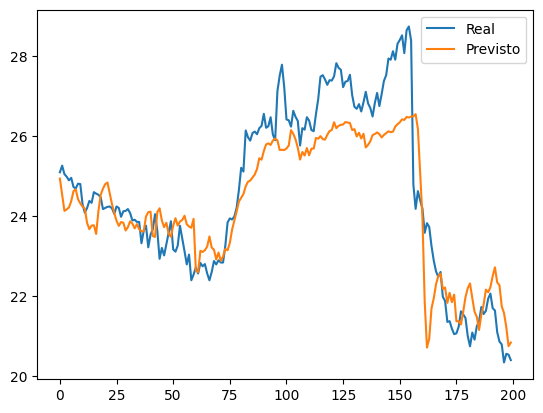

In [ ]:
import matplotlib.pyplot as plt

plt.plot(y_test_real[:200], label='Real')
plt.plot(y_pred_real[:200], label='Previsto')
plt.legend()
plt.show()

In [ ]:
print("y_test min/max:", y_test.min(), y_test.max())

y_test min/max: 0.8915390519369899 3.591976359973321


In [ ]:
model.save("modelo_tf")

In [ ]:
import joblib

joblib.dump(scaler_x, r"C:\Users\gerem\Desktop\projeto_tc_fiap_4\models_artifacts/scaler_x.pkl")
joblib.dump(scaler_y,r"C:\Users\gerem\Desktop\projeto_tc_fiap_4\models_artifacts/scaler_y.pkl")

['C:\\Users\\gerem\\Desktop\\projeto_tc_fiap_4\\models_artifacts/scaler_y.pkl']

In [ ]:
print("std real:", np.std(y_test_real))
print("std pred:", np.std(y_pred_real))